# Propiedad del Mundo Pequeño en redes aleatorias

Recordemos que en una red aleatoria con $n$ nodos, probabilidad de enlace $p$ y grado promedio $\langle k\rangle$, la distribución de grados $p_k$ sigue una distribución binomial (y Poisson para $n$ suficientemente grande). Es decir, la mayoría de los nodos tienen grado $\langle k\rangle$.

Si consideramos un nodo arbitrario $n_0$, con seguridad podemos decir que desde $n_0$ hay:

- $\langle k\rangle$ nodos a distancia $d=1$,
- $\langle k\rangle^2$ nodos a distancia $d=2$,
- $\langle k\rangle^3$ nodos a distancia $d=3$,

En general,

- $\langle k\rangle^d$ nodos a distancia $d$ de $n_0$.

Sea $N(d)$ nodos a distancia $d$ de $n_0$. Entonces

$$N(d)=1+\langle k\rangle+\langle k\rangle^2+\ldots+\langle k\rangle^d=\frac{1-\langle k\rangle^{d+1}}{1-\langle k\rangle}$$

Por otro lado, si denotamos por $d_{\max}$ al diámetro de la red, entonces $$N(d_{\max})\approx n$$

Sustituyendo en la anterior igualdad,

$$N(d_{\max})=\frac{1-\langle k\rangle^{d_{\max}+1}}{1-\langle k\rangle}\approx n$$

Para redes muy grandes, el grado promedio es mucho mayor a 1, por lo que podemos despreciar al 1 en la expresión, por tanto,

$$n\approx\frac{1-\langle k\rangle^{d_{\max}+1}}{1-\langle k\rangle}\approx\frac{-\langle k\rangle^{d_{\max}+1}}{-\langle k\rangle}=\langle k\rangle^{d_{\max}}$$

Aplicando logaritmos, tenemos que la distancia máxima entre dos nodos está dada por

$$d_{\max}=\frac{\log(n)}{\log(\langle k\rangle)}$$

Es decir, la distancia máxima entre dos nodos de la red, es proporcional al logaritmo del tamaño de la red. A esto se le conoce como Propiedad del mundo Pequeño.

$\textbf{Actividad}:$ Investiga la población mundial y, usando logaritmo (base 10, por ejemplo), estima la distancia máxima en la red de la población mundial (Nota: no tiene que ser exacto).

    La poblacion mundial se obtuvo de https://populationtoday.com/es/

In [34]:
import numpy as np

n = int(np.log(8_285_310_000))
k = 100
d_max = n/np.log(k)
print(d_max)

4.777239300935769


In [35]:
n

22

    ?!?!?!?!?! Se tiene que, si todos conocemos a 100 personas (en promedio), en promedio estamos a 4.77 personas de cualquier persona del mundo

# Introducción al modelo de Watts-Strogatz

In [36]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Comencemos con una red anillo con $n$ nodos en un ciclo y cada nodo está conectado con $c$ nodos más cercanos; es decir, $\frac{c}{2}$ vecinos a la izquierda y $\frac{c}{2}$ vecinos a la derecha. Definamos $l=\frac{c}{2}$.

Definamos la red anillo regular con $n$ nodos y $c=2l$ vecinos más cercanos.

In [37]:
def Anillo(n, l = 2):
    nodos = np.arange(n)
    G = nx.Graph()
    G.add_nodes_from( nodos )
    
    for i in range(l):
        G.add_edges_from( zip( nodos, np.roll(nodos, i+1) ) )
    return G

Cambia los parámetros de $n$ y $l$ para ver cómo se modifica el coeficiente (promedio) de clustering.

el coeficiente de clustering de la red es :  0.5


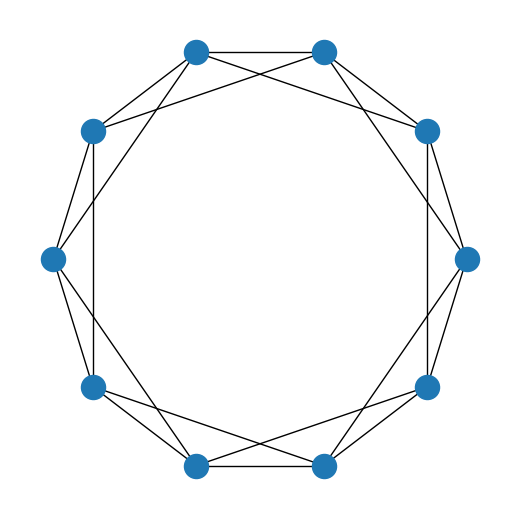

In [38]:
G = Anillo(10, 2) #
print('el coeficiente de clustering de la red es : ', nx.clustering(G)[0])
plt.figure(figsize = [5,5])
nx.draw_circular(G)

También se puede ver cómo se modifica el diámetro de la red.

In [39]:
nx.diameter(G)

3

En el siguiente código, distinguimos al primer nodo que fue añadido a la red (con color rojo), para tenerlo como referencia cuando la red sea modificada. Cambia los parámetros y observa cómo se modifica el coeficiente de clustering y el diámetro.

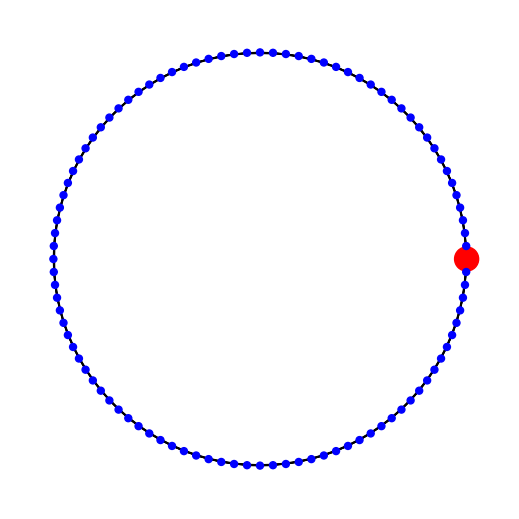

Clustering =  0.6
Diametro =  17


In [40]:
G = Anillo(100,3)

n = len(G)
tamanos = [300]
tamanos = tamanos + (n-1)*[25]
colores = ['red']
colores = colores + (n-1)*['blue']

plt.figure(figsize = [5,5])
nx.draw_circular(G, node_size = tamanos, node_color = colores)
plt.show()

print('Clustering = ', nx.average_clustering(G) ) 
print('Diametro = ', nx.diameter(G) ) 

$\textbf{Responde:}$

- ¿Se puede decir que la red generada tiene la propiedad del mundo pequeño?
	No, porque para $n=100$ y $l=3$ el diámetro es $17$, mucho mayor que la estimación logarítmica de una red de mundo pequeño ($\approx 2.57$).
- Si los nodos se conectan a más vecinos, ¿hay alguna relación enetre el diámetro de la red con el parámetro $l$?
	Sí. Al aumentar $l$, cada nodo se conecta con más vecinos y el diámetro disminuye; aproximadamente decrece de manera inversa a $l$.

In [41]:
50/3

16.666666666666668

In [42]:
np.log(100)/np.log(6)

np.float64(2.570194417876938)

## Matriz de distancia

Podemos visualizar las distancias entre cada par de nodos. Generamos la matriz de distancias, una matriz cuadrada de $n\times n$ en donde la entrada $ij$ es la distancia geodésica entre los nodos $i$ y $j$. Usamos la función shortest_path_length de NetworkX.

In [43]:
MatD0 = np.zeros([n,n]) #Generamos una matriz de ceros
for i in range(n):
    for j in range(n):
        MatD0[i,j] = nx.shortest_path_length(G, i, j) #Agregamos la distancia entre los nodos i y j a la entrada ij
dmin = np.min(MatD0)
dmax = np.max(MatD0)

Podemos visualizar la matriz de distancias junto con la red. Colores cálidos (amarillo) representan parejas de nodos con distancia grande y colores fríos (azul) representan nodos con distancia pequeña, como lo muestra la barra vertical. Notemos que en la disagonal tenemos color negro (la distancia de un nodo con sus próximos vecinos (y sí mismo) es muy pequeña).

Cambia los parámetros de la red ($n$ y $l$) y observa cómo se modifican las distancias y el coeficiente de clustering.

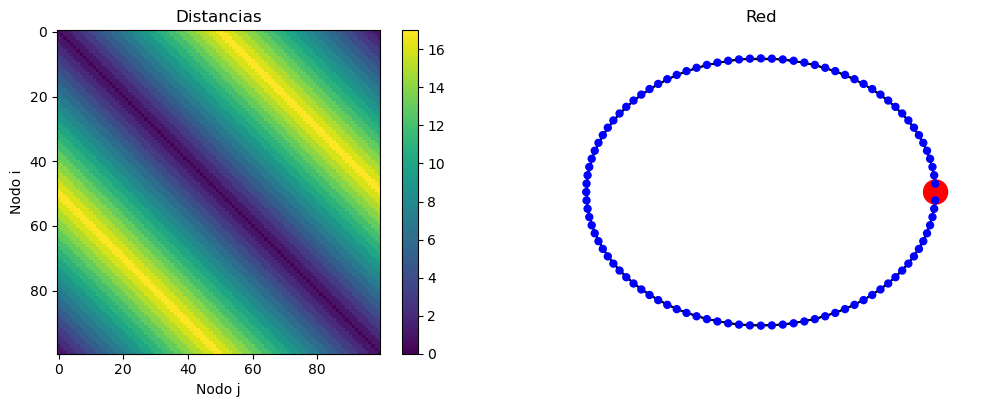

Distancia máxima entre nodos (diámetro): 	 17.0
Distancia promedio entre nodos: 		 8.67
Coeficiente de clustering promedio de la red: 	 0.6


In [44]:
h = .6 #parametro para modificar el tamaño de la imagen
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G, node_size = tamanos, node_color = colores, ax = ax2)


pos = ax1.imshow(MatD0, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)

ax1.set_title('Distancias')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red')
plt.show()

print('Distancia máxima entre nodos (diámetro): \t', np.max(MatD0))
print('Distancia promedio entre nodos: \t\t', np.mean(MatD0))
print('Coeficiente de clustering promedio de la red: \t', nx.average_clustering(G))

# Variante del Modelo

Recordemos que el Modelo de Watts-Strogatz nos dice que, una vez que tenemos una red anillo, elegimos una arista y con probabilidad $p$ la removemos y la reemplazamos con una arista que una a dos nodos elegidos de forma aleatoriamente uniforme. Estas nuevas aristas se llaman $\textbf{atajos}$, que nos permiten disminuir la distancia máxima (diámetro) de la red.

Comenzaremos analizando una variante del modelo. Vamos a seleccionar un nodo $n_1$ de forma aleatoria, seleccionamos un vecino de $n_1$, digamos $n_2$, también de forma aleatoria, quitamos la arista $(n_1,n_2)$, después, entre los nodos restantes de la red elegimos uno al azar, digamos $n_3$, y se agrega la arista $(n_1,n_3)$.

In [45]:
def cambio_enlace(G):
  # ojo con el uso de los conjutos (set)
  nodo1 = np.random.choice(G)
  nodo2 = np.random.choice( G[nodo1] )
  G.remove_edge(nodo1, nodo2)
  seleccion = set(G) - set(G[nodo1]) - set([nodo1])
  
  nuevo_nodo = np.random.choice( list(seleccion) )
  
  G.add_edge(nodo1, nuevo_nodo)

Para visualizar cómo cambió la red, generamos una copia de la red original:

- Genera una red anillo (puedes usar otros parámetros).
- Ejecuta la celda "Modificación de redes". Esta celda modifica la red paso a paso, puedes ejecutarla varias veces para ver cómo se va modificando la red.
- Puedes usar otros parámetros ejecutando nuevamente la celda "Genera las redes".

$\textbf{Responde}:$
 - Al modificar la red una vez, ¿se disminuye el diámetro? ¿Por qué?
	No necesariamente. Un solo cambio puede bajar la distancia promedio, pero el diámetro puede quedarse igual si no afecta a los caminos más largos.
 - ¿Qué característica tienen los nuevos enlaces que disminuyen mucho la distancia promedio?
	Son atajos largos que conectan regiones lejanas de la red y unen nodos que antes estaban a gran distancia geodésica.
 - ¿Qué característica tienen los nuevos enlaces que casi no disminuyen la distancia promedio?
	Suelen unir nodos que ya estaban cerca o dentro de la misma vecindad local, así que son enlaces casi redundantes.
 - ¿El coeficiente de clustering puede disminuir a la mitad? ¿Cuántos pasos se necesitarían? Si es el caso, ¿qué pasó con la distancia promedio y el diámetro?
	Sí, pero hacen falta bastantes cambios. En corridas con $n=100$ y $l=3$ se necesitó del orden de $70$ a $90$ pasos; para entonces la distancia promedio y el diámetro ya habían disminuido mucho.

In [46]:
# Genera las redes

n = 100
l = 3

G = Anillo(n, l)

G2 = G.copy()

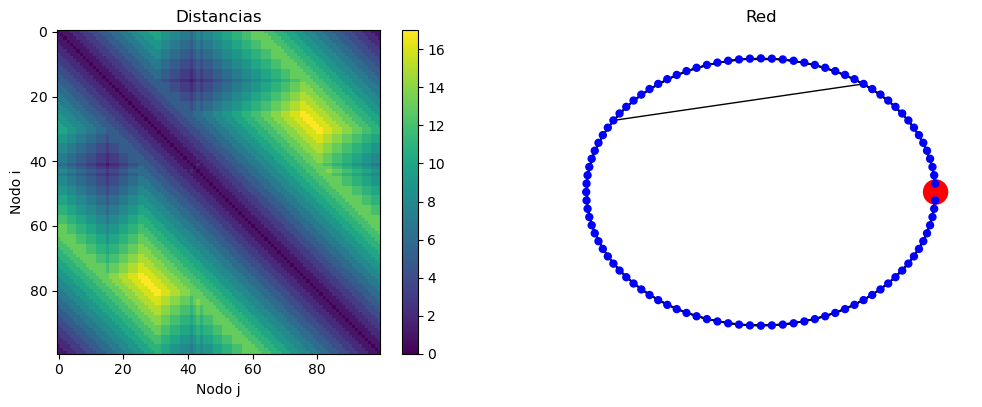

Diametro: 		 17.0 --> 17.0
Distancia media: 	 8.67 --> 7.4978
Clustering: 		 0.6 --> 0.5942857142857142


In [47]:
# Modificación de la red

cambio_enlace(G2)

MatD = np.zeros([n,n])
for i in range(n):
    for j in range(n):
        MatD[i,j] = nx.shortest_path_length(G2, i, j)

        
        
h = .6

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G2, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)
ax1.set_title('Distancias')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red')

plt.show()
print('Diametro: \t\t', np.max(MatD0), '-->',np.max(MatD))
print('Distancia media: \t', np.mean(MatD0), '-->', np.mean(MatD))
print('Clustering: \t\t', nx.average_clustering(G), '-->', nx.average_clustering(G2))

Se puede generar un ciclo para hacer varios enlaces en un mismo paso.

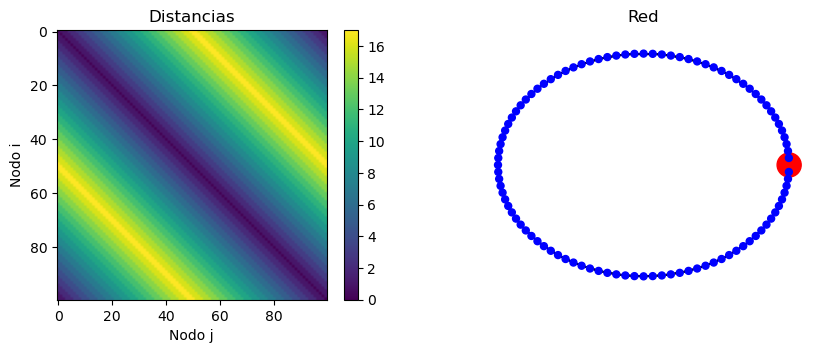

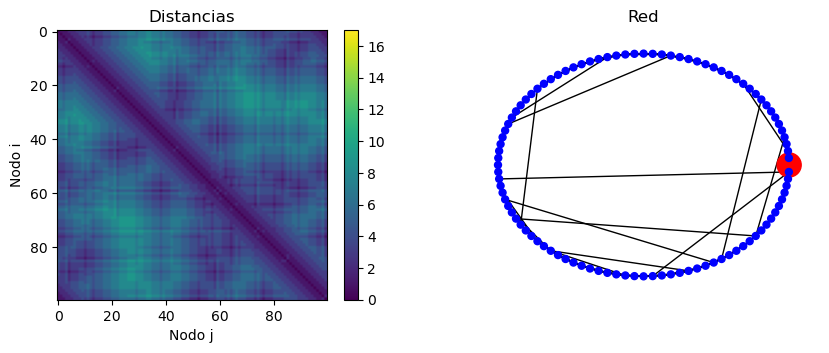

Diametro:  17.0 --> 9.0
Distancia media:  8.67 --> 4.5158
Clustering:  0.6 --> 0.5116428571428571


In [48]:
G2 = G.copy()

veces = 15

for k in range(veces):
    cambio_enlace(G2)


MatD = np.zeros([n,n])

for i in range(n):
    for j in range(n):
        MatD[i,j] = nx.shortest_path_length(G2, i, j)

        
        
h = .5

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD0, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)

ax1.set_title('Distancias')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red')
plt.show()


fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize = (20*h,7*h)) 
nx.draw_circular(G2, node_size = tamanos, node_color = colores, ax = ax2)


#fig, ax = plt.subplots(figsize = (10*h,7*h)) 
pos = ax1.imshow(MatD, vmin=dmin, vmax=dmax)
fig.colorbar(pos, ax=ax1)
ax1.set_title('Distancias')
ax1.set_xlabel('Nodo j')
ax1.set_ylabel('Nodo i')

ax2.set_title('Red')

plt.show()
print('Diametro: ', np.max(MatD0), '-->',np.max(MatD))
print('Distancia media: ', np.mean(MatD0), '-->', np.mean(MatD))
print('Clustering: ', nx.average_clustering(G), '-->', nx.average_clustering(G2))

$\textbf{Actividad}:$ 

- Genera una red.
- Genera una lista para el diámetro, la distancia promedio y el coeficiente de clustering. EL primer elemento de la lista es el valor de la variable de la red inicial.
- Aplica la función cambio_enlace varias veces (define cuantas veces), y cada vez que lo apliques, calcula los nuevos valores y agrégalos a la lista usando lista.append(valor). Para ello haz un bucle usando k.
- Grafica las listas de valores generados. El diámetro y la distancia promedio se grafican juntas, el clustering aparte.

In [49]:
#Genera la red anillo
n = 100
l = 3

G = Anillo(n,l)

G2 = G.copy()

In [50]:
# Generar una lista para cada variable.

Diam = [nx.diameter(G2)]
Dist = [nx.average_shortest_path_length(G2)]
Clus = [nx.average_clustering(G2)]


In [51]:
# Aplica la fucnión cambio_enlace varias veces

k = 20 #numero de veces que se aplicará la función

for i in range(k):
    cambio_enlace(G2)
    Diam.append(nx.diameter(G2))
    Dist.append(nx.average_shortest_path_length(G2))
    Clus.append(nx.average_clustering(G2))

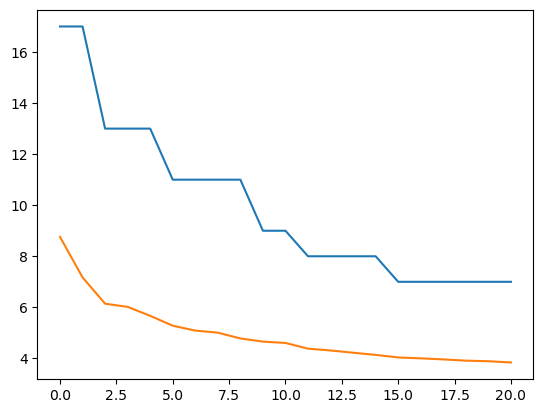

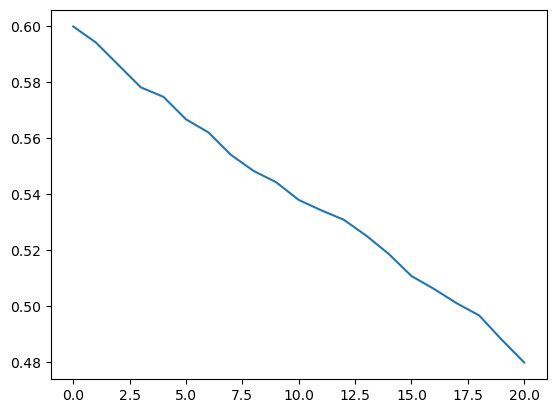

In [52]:
# Grafica
plt.plot(Diam)
plt.plot(Dist)
plt.show()


plt.plot(Clus)
plt.show()

$\textbf{Responde:}$

- ¿Qué se puede decir respecto al comportamiento de las distancias y el clustering?
- ¿Cómo decaen?
- ¿Cuál decae primero?

$\textbf{Actividad}:$ Ejecuta varias veces la actividad anterior, guarda la información de cada ejecución y al final haz un promedio. Se sugieren no más de 15 ejecuciones.

In [53]:
# Se generan las listas donde se introducirán las listas de los valores de cada corrida.
n = 100
l = 3

G = Anillo(n,l)


DIAM = []
DIST = []
CLUS = []

ejecuciones = 10

for j in range(ejecuciones):
    #### Haz lo mismo que hiciste en la actividad anterior, pero ahora dentro de este bucle para que se haga varias veces
    G2 = G.copy()

    #crea las listas de cada variable aplicada a G2

    Diam = [nx.diameter(G2)]
    Dist = [nx.average_shortest_path_length(G2)]
    Clus = [nx.average_clustering(G2)]

    k = 20 # numero de cambio de enlaces
    for i in range(k):
      cambio_enlace(G2)
      Diam.append(nx.diameter(G2))
      Dist.append(nx.average_shortest_path_length(G2))
      Clus.append(nx.average_clustering(G2))

    #### 
    
    #las siguientes lineas agregan la información de cada ejecución a una lista
    DIAM.append(Diam)
    DIST.append(Dist)
    CLUS.append(Clus)

Hacemos el promedio de cada lista sobre todas las ejecuciones.

In [54]:
Y1 = np.mean(np.array(DIAM), axis = 0)
Y2 = np.mean(np.array(DIST), axis = 0)
Y3 = np.mean(np.array(CLUS), axis = 0)

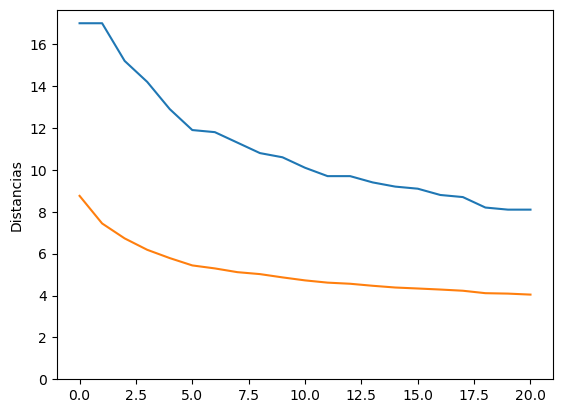

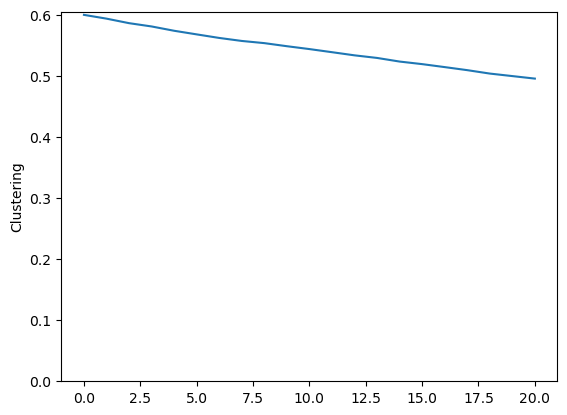

In [55]:
plt.plot(Y1)
plt.plot(Y2)
plt.ylim([0,None])
plt.xlabel('Cambios de enlace')
plt.ylabel('Distancias')
plt.legend(['Diametro promedio', 'Distancia promedio'])
plt.show()

plt.plot(Y3)
plt.ylim([0,None])
plt.xlabel('Cambios de enlace')
plt.ylabel('Clustering')
plt.legend(['Clustering promedio'])
plt.show()

¿Puedes decir algo sobre el comportamiento de las distancias y el clustering? ¿Cómo decaen? ¿Cuál decae más rápido?
	Sí. En promedio ambas cantidades disminuyen conforme aumentan los cambios de enlace.
	La distancia promedio cae rápido al inicio y luego más lentamente, mientras que el clustering desciende de forma más gradual.
	La distancia promedio es la que decae más rápido.
	Por ejemplo, después de 20 cambios el diámetro promedio pasó de 17 a aproximadamente 8.2, la distancia promedio de 8.76 a aproximadamente 4.02 y el clustering solo de 0.60 a aproximadamente 0.50.

# El Modelo de Watts-Strogatz

Generamos una función más apegada el modelo (¿es el modelo visto en clase? ¿Por qué?). Partimos de una red anillo a la cual se le cambian un porcentaje de aristas dadas por una probabilidad $0\leq p\leq 1$.

La función toma una red $G$ y una probabilidad $p$, recorre todas las aristas originales y con probabilidad $p$ las modifica.

In [56]:
def re_enlazar(G, p):
  nodos = set(G)
  
  for enlace in list(G.edges()):
    if np.random.rand() < p:
      u, v = enlace
      eleccion = nodos -{u} - set(G[u])
      if len(eleccion) == 0:
        continue
      nuevo_v = np.random.choice( list(eleccion) )
      G.remove_edge(u,v)
      G.add_edge(u, nuevo_v)

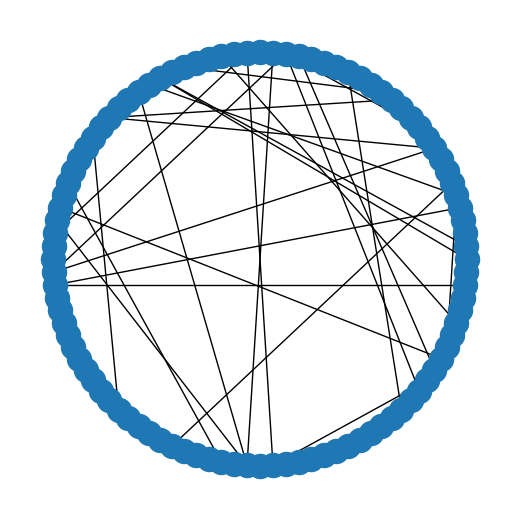

In [57]:
n = 100
l = 3

G = Anillo(n, l)

re_enlazar(G, .1)

plt.figure(figsize = [5,5])
nx.draw_circular(G)

$\textbf{Actividad:}$ Realiza las actividades anteriores usando esta función y cambiando valores de $p$. ¿Qué diferencia hay con valores pequeños y grandes de $p$? También puedes usar la función de NetworkX: https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.watts_strogatz_graph.html#
	Con valores pequeños de $p$ aparecen pocos atajos, pero eso ya alcanza para reducir bastante la distancia promedio mientras el clustering sigue alto.
	Con valores grandes de $p$ la red se vuelve cada vez más aleatoria: la distancia promedio es muy pequeña, pero el coeficiente de clustering cae de forma marcada.
	Eso coincide con la idea central del modelo de Watts-Strogatz: unas pocas reconexiones cambian mucho las distancias globales sin destruir inmediatamente la estructura local.

# Experimento

Recordemos que cuando $p=1$, tenemos una red aleatoria (del modelo de Erdös-Renyi), la cual tiene la propiedad del mundo pequeño pero coeficiente de clustering (promedio) bajo; y cuando $p=0$ tenemos una red anillo que tiene coeficiente de clustering alto pero no tiene la propiedad del mundo pequeño. Hay un rango de valores intermedios de $p$, donde las redes generadas tienen ambas propiedades.

Comenzaremos generando varias redes y haciendo una lista de sus distancia promedio y clustering, para después graficarlos. Prueba a cambiar los parámetros.

In [58]:
n = 100
l = 2

E = 100 #La cantidad de redes generadas

p = 0.3

D = []
C = []

# Generemos varias redes con un ciclo
while len(D)<E:
    G = Anillo(n, l)
    re_enlazar(G, p)
    if not nx.is_connected(G): continue #En caso de que la red no sea conexa, no se puede calcular la distancia promedio
    D.append(nx.average_shortest_path_length(G))
    C.append(nx.average_clustering(G))
print(np.mean(D),np.mean(C))

3.859951515151516 0.19096792207792204


Ahora podemos variar el valor de $p$ en un ciclo, generando varias redes para cada valor de $p$. Prueba a cambiar los parámetros y observa cómo cambian $D$ y $C$.

In [59]:
n = 100
l = 2

E = 100 #La cantidad de redes generadas

for p in [.1,.2,.3]:
    D = []
    C = []

    # Generemos varias redes con un ciclo
    while len(D)<E:
        G = Anillo(n, l)
        re_enlazar(G, p)
        if not nx.is_connected(G): continue #En caso de que la red no sea conexa, no se puede calcular la distancia promedio
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    print(np.mean(D),np.mean(C))

5.123070707070708 0.3808180952380952
4.186248484848485 0.27370746031746035
3.863535353535354 0.1962219047619048


Vamos a guardar estos valores en una lista, para después graficarlos. Prueba a cambiar los parámetros.

In [60]:
n = 100
l = 2

E = 100 #La cantidad de redes generadas

Dist = []
Clus = []

dominio = [.1,.2,.3]

for p in dominio:
    D = []
    C = []

    # Generemos varias redes con un ciclo
    while len(D)<E:
        G = Anillo(n, l)
        re_enlazar(G, p)
        if not nx.is_connected(G): continue #En caso de que la red no sea conexa, no se puede calcular la distancia promedio
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D))
    Clus.append(np.mean(C))
    #print(np.mean(D),np.mean(C))

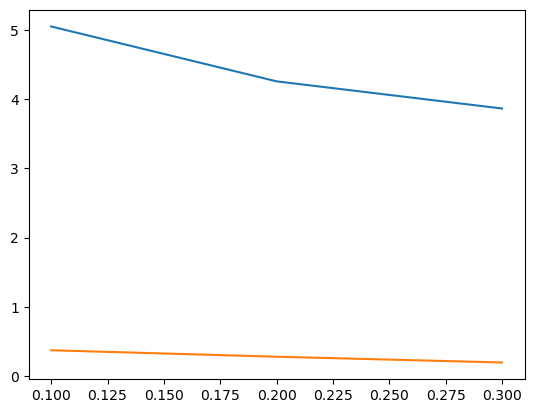

In [61]:
plt.plot(dominio,Dist, label = 'Distancia promedio')
plt.plot(dominio,Clus, label = 'Clustering promedio')
plt.xlabel('p')
plt.ylabel('Valor promedio')
plt.legend()

Interpretación de la gráfica anterior:
	Para $p=0.1, 0.2$ y $0.3$, tanto la distancia promedio como el clustering disminuyen al aumentar $p$.
	Eso indica que, al re-enlazar más aristas, la red se hace más eficiente globalmente pero pierde parte de su estructura local.
	En este rango intermedio el clustering ya empieza a caer con fuerza, así que conviene mirar valores de $p$ más pequeños para identificar mejor la región de mundo pequeño.

Vamos a tomar más valores de $p$ para tener una mejor idea de cómo cambian al momento de graficar.

In [62]:
n = 100
l = 2

E = 100 #La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.arange(.1,.6,.01) #los valores de p van desde .1 hasta .6, cada .01

for p in dominio:
    D = []
    C = []

    # Generemos varias redes con un ciclo
    while len(D)<E:
        G = Anillo(n, l)
        re_enlazar(G, p)
        if not nx.is_connected(G): continue #En caso de que la red no sea conexa, no se puede calcular la distancia promedio
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D))
    Clus.append(np.mean(C))

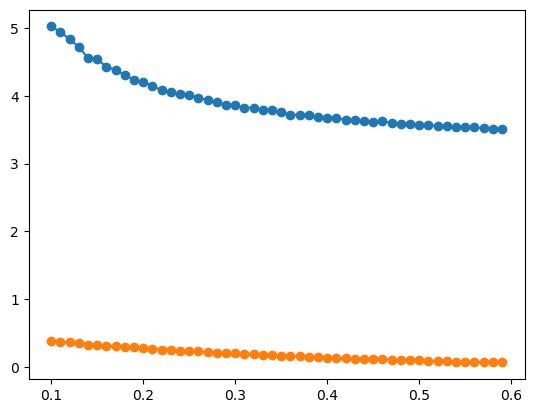

In [63]:
plt.plot(dominio,Dist, 'o-', label = 'Distancia promedio')
plt.plot(dominio,Clus, 'o-', label = 'Clustering promedio')
plt.xlabel('p')
plt.ylabel('Valor promedio')
plt.legend()

Interpretación de la gráfica anterior:
	Cuando se toman más valores de $p$ entre $0.1$ y $0.6$, la distancia promedio sigue bajando de manera suave, pero el clustering desciende mucho más hasta acercarse a valores muy pequeños.
	Esto sugiere que en ese rango la red ya se está volviendo bastante aleatoria: conserva distancias cortas, pero la agrupación local casi desaparece.

Para tener una mejor visualización, vamos a "normalizar". Dividimos por la distancia promedio inicial y el coficiente de clustering inicial. Además, graficamos usando escala logarítmica.

In [64]:
n = 100
l = 2
G=Anillo(n,l)
D0 = nx.average_shortest_path_length(G) # Distancia promedio inicial
C0 = nx.average_clustering(G) # Clustering promedio inicial

E = 10 #La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.arange(.01,.6,.01)

for p in dominio:
    D = []
    C = []

    # Generemos varias redes con un ciclo
    while len(D)<E:
        G = Anillo(n, l)
        re_enlazar(G, p)
        if not nx.is_connected(G): continue #En caso de que la red no sea conexa, no se puede calcular la distancia promedio
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0) #Normalizamos
    Clus.append(np.mean(C)/C0) #Normalizamos

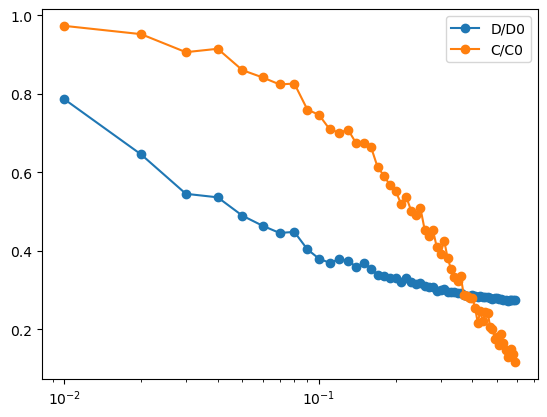

In [65]:
plt.plot(dominio,Dist, 'o-', label = 'D/D0')
plt.plot(dominio,Clus, 'o-', label = 'C/C0')
plt.xscale('log') # Graficamos en escala logarítmica
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.legend()

Interpretación de la gráfica anterior:
	En la escala logarítmica se aprecia mejor que $D/D_0$ empieza a bajar desde valores pequeños de $p$, mientras que $C/C_0$ se mantiene cerca de $1$ durante más tiempo.
	Eso significa que unas pocas reconexiones reducen bastante las distancias globales sin destruir inmediatamente la estructura local.
	Las curvas se acercan y se cruzan aproximadamente en la región $p\approx 0.3$ a $0.4$ en estas corridas.
	Antes de esa zona la red todavía conserva clustering relativamente alto; después de esa zona ya se comporta de forma mucho más aleatoria.

Vamos a tomar valores de $p$ usando la función np.logspace (similar a linspace).

In [66]:
n = 100
l = 2
G=Anillo(n,l)
D0 = nx.average_shortest_path_length(G) # Distancia promedio inicial
C0 = nx.average_clustering(G) # Clustering promedio inicial

E = 10 #La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.logspace(-4,0,20) #Potencia de 10 inicial, potencia de 10 inicial y cantidad de puntos

for p in dominio:
    D = []
    C = []

    # Generemos varias redes con un ciclo
    while len(D)<E:
        G = Anillo(n, l)
        re_enlazar(G, p)
        if not nx.is_connected(G): continue #En caso de que la red no sea conexa, no se puede calcular la distancia promedio
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0) #Normalizamos
    Clus.append(np.mean(C)/C0) #Normalizamos

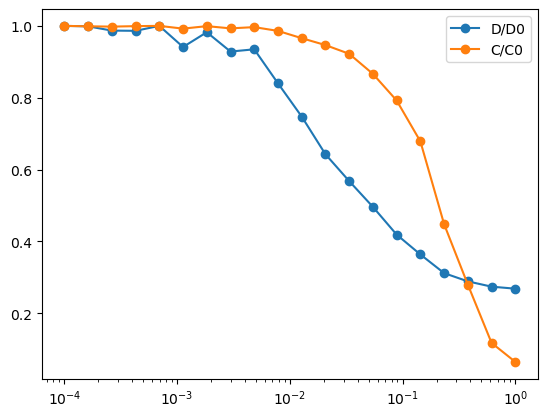

In [67]:
plt.plot(dominio,Dist, 'o-', label = 'D/D0')
plt.plot(dominio,Clus, 'o-', label = 'C/C0')
plt.xscale('log') # Graficamos en escala logarítmica
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.legend()

Interpretación de la gráfica anterior:
	Esta es la gráfica que muestra más claramente el efecto Watts-Strogatz.
	Para valores muy pequeños de $p$, la distancia normalizada ya cayó de forma importante, pero el clustering normalizado sigue cerca de $1$.
	Esa separación entre ambas curvas identifica la región de mundo pequeño: la red gana caminos cortos sin perder todavía su agrupación local.

Prueba ahora a cambiar la cantidad de nodos a valores de $n$ grandes (de preferencia 1000 con $l=5$, pero puede tardar mucho tiempo en ejecutarse).

In [68]:
n = 200
l = 5
G=Anillo(n,l)
D0 = nx.average_shortest_path_length(G) # Distancia promedio inicial
C0 = nx.average_clustering(G) # Clustering promedio inicial

E = 20 #La cantidad de redes generadas

Dist = []
Clus = []

dominio = np.logspace(-4,0,20) #Potencia de 10 inicial, potencia de 10 inicial y cantidad de puntos

for p in dominio:
    D = []
    C = []

    # Generemos varias redes con un ciclo
    while len(D)<E:
        G = Anillo(n, l)
        re_enlazar(G, p)
        if not nx.is_connected(G): continue #En caso de que la red no sea conexa, no se puede calcular la distancia promedio
        D.append(nx.average_shortest_path_length(G))
        C.append(nx.average_clustering(G))
    Dist.append(np.mean(D)/D0) #Normalizamos
    Clus.append(np.mean(C)/C0) #Normalizamos

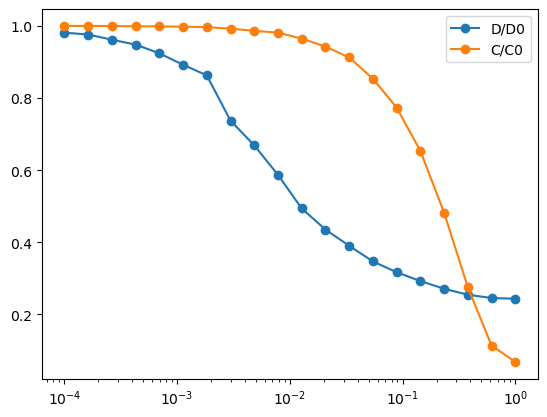

In [69]:
plt.plot(dominio,Dist, 'o-', label = 'D/D0')
plt.plot(dominio,Clus, 'o-', label = 'C/C0')
plt.xscale('log') # Graficamos en escala logarítmica
plt.xlabel('p')
plt.ylabel('Valor normalizado')
plt.legend()

$\textbf{Actividad:}$ Cambia los parámetros y determina un intervalo de valores de $p$ en el cual se cumplen ambas propiedades: Propiedes de Mundo Pequeño (distancias cortas) y Coeficiente de Clustering alto.
	Un intervalo razonable es $p \approx 10^{-2}$ a $10^{-1}$. En estas corridas se observó aproximadamente entre $0.02$ y $0.09$ para $n=100$ y $l=2$.
	Si se usan más nodos, el intervalo puede empezar un poco antes; por ejemplo, con $n=200$ y $l=5$ la zona favorable apareció aproximadamente desde $p\approx 0.005$ hasta cerca de $0.09$.
	En la última gráfica se ve que, al aumentar el tamaño de la red, el patrón se conserva: la distancia cae antes que el clustering.
	En esa región la distancia ya bajó bastante respecto a la red inicial, pero el clustering todavía conserva una fracción grande de su valor original.